In [2]:
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)


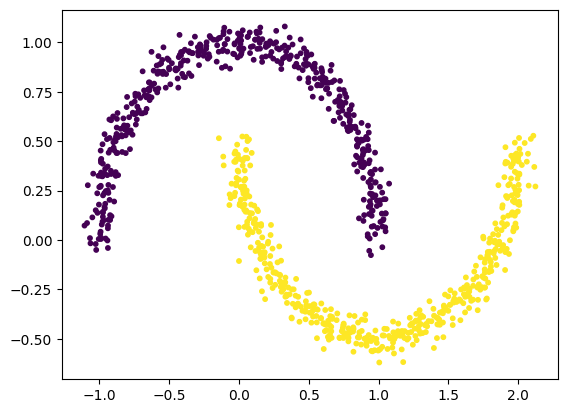

In [6]:
from matplotlib import pyplot as plt
plt.scatter(
    x=X_moons[:, 0], 
    y=X_moons[:,1], c=y_moons, cmap='viridis', s=10
)
plt.show()

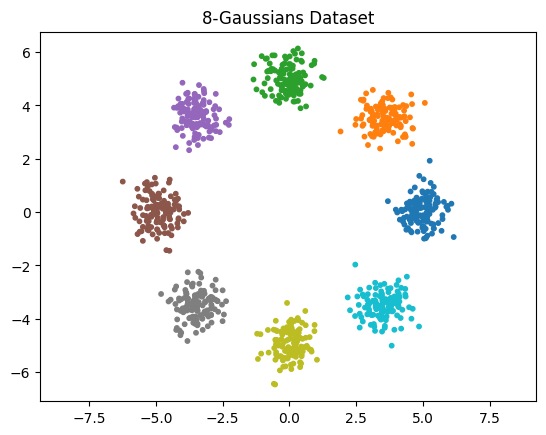

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Calculate 8 symmetrically arranged centers on a circle of radius 5
angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
centers = np.column_stack((5 * np.cos(angles), 5 * np.sin(angles)))

# Generate the 8 distinct blobs
X_gaussians, y_gaussians = make_blobs(
    n_samples=1000, 
    centers=centers, 
    cluster_std=0.5, 
    random_state=42
)

# Plot
plt.scatter(X_gaussians[:, 0], X_gaussians[:, 1], c=y_gaussians, cmap='tab10', s=10)
plt.title("8-Gaussians Dataset")
plt.axis('equal')
plt.show()


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import MixtureSameFamily, Categorical, MultivariateNormal
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# 1. Prepare Data
X_np, _ = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_train = torch.tensor(X_np, dtype=torch.float32)

# 2. Define the GMM Model
class GaussianMixtureModel(nn.Module):
    def __init__(self, n_features=2, n_components=10):
        super().__init__()
        self.n_features = n_features
        self.n_components = n_components
        
        # Mixing weights (logits) for the clusters
        self.mix_logits = nn.Parameter(torch.zeros(n_components))
        
        # Means for each Gaussian component
        self.means = nn.Parameter(torch.randn(n_components, n_features))
        
        # Covariances: Using diagonal matrices for simplicity (unconstrained variances)
        # We store log variances to keep them strictly positive using exp()
        self.log_vars = nn.Parameter(torch.zeros(n_components, n_features))
        
    def get_distribution(self):
        # 1. Cluster probabilities (softmax ensures they sum to 1)
        mix = Categorical(logits=self.mix_logits)
        
        # 2. Component distributions (diagonal covariances)
        cov_matrices = torch.diag_embed(torch.exp(self.log_vars))
        comp = MultivariateNormal(self.means, covariance_matrix=cov_matrices)
        
        # 3. Combined GMM Distribution
        return MixtureSameFamily(mix, comp)
    
    def forward(self, x):
        dist = self.get_distribution()
        # Returns the log-likelihood for MLE optimization
        return dist.log_prob(x)


Epoch 100/500 | Loss (Negative Log-Likelihood): 0.9491
Epoch 200/500 | Loss (Negative Log-Likelihood): 0.7956
Epoch 300/500 | Loss (Negative Log-Likelihood): 0.7623
Epoch 400/500 | Loss (Negative Log-Likelihood): 0.7615
Epoch 500/500 | Loss (Negative Log-Likelihood): 0.7615


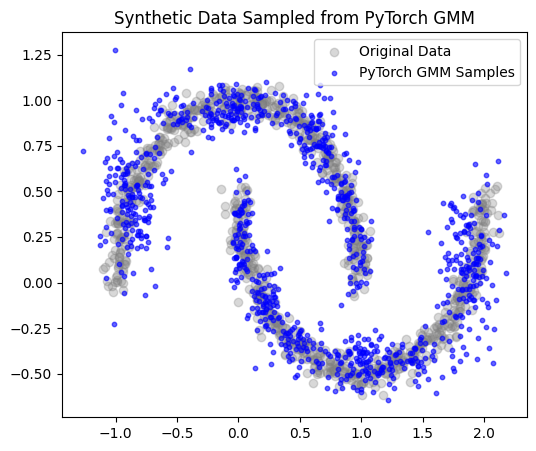

In [ ]:

# 3. Instantiate Model & Optimizer
model = GaussianMixtureModel(n_features=2, n_components=10)
optimizer = optim.Adam(model.parameters(), lr=0.1)

# 4. Training Loop (Maximizing Log-Likelihood via Gradient Descent)
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Calculate log-likelihood of our data points
    log_likelihood = model(X_train)
    
    # MLE means maximizing log-likelihood, which is minimizing NEGATIVE log-likelihood
    loss = -log_likelihood.mean() 
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss (Negative Log-Likelihood): {loss.item():.4f}")

# 5. Generate and sample new data points from the trained PyTorch GMM
with torch.no_grad():
    gmm_dist = model.get_distribution()
    X_samples = gmm_dist.sample((1000,)) # Draw 400 new synthetic samples

# --- Visualization ---
plt.figure(figsize=(6, 5))
plt.scatter(X_np[:, 0], X_np[:, 1], color='gray', alpha=0.3, label='Original Data')
plt.scatter(X_samples[:, 0], X_samples[:, 1], color='blue', alpha=0.6, s=10, label='PyTorch GMM Samples')
plt.title("Synthetic Data Sampled from PyTorch GMM")
plt.legend()
plt.show()


## RealNVP normalizing flow on 2D